### HYPERPARAMETER OPTIMIZATION EXAMPLE

=== HYPERPARAMETER OPTIMIZATION DEMONSTRATION ===

1. Generating synthetic financial dataset...
Dataset shape: (1000, 10)
Target variable: Asset_Returns
Features: ['Factor_1', 'Factor_2', 'Factor_3', 'Factor_4', 'Factor_5', 'Factor_6', 'Factor_7', 'Factor_8', 'Factor_9', 'Factor_10']

2. Splitting data into training and testing sets...
Training set: 800 samples
Testing set: 200 samples

3. Setting up Random Forest with hyperparameter distributions...
Hyperparameter distributions for Random Search:
  n_estimators: [50, 100, 200, 300, 500]
  max_depth: [None, 5, 10, 15, 20, 30]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 4]
  max_features: ['auto', 'sqrt', 'log2', 0.7, 0.8]
  bootstrap: [True, False]

4. Performing Randomized Search with 5-fold Cross-Validation...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Randomized Search completed!

5. RANDOMIZED SEARCH RESULTS:
Best Cross-Validation Score (Negative MSE): -469.1450
Best Hyperparameters Found:
  n_esti

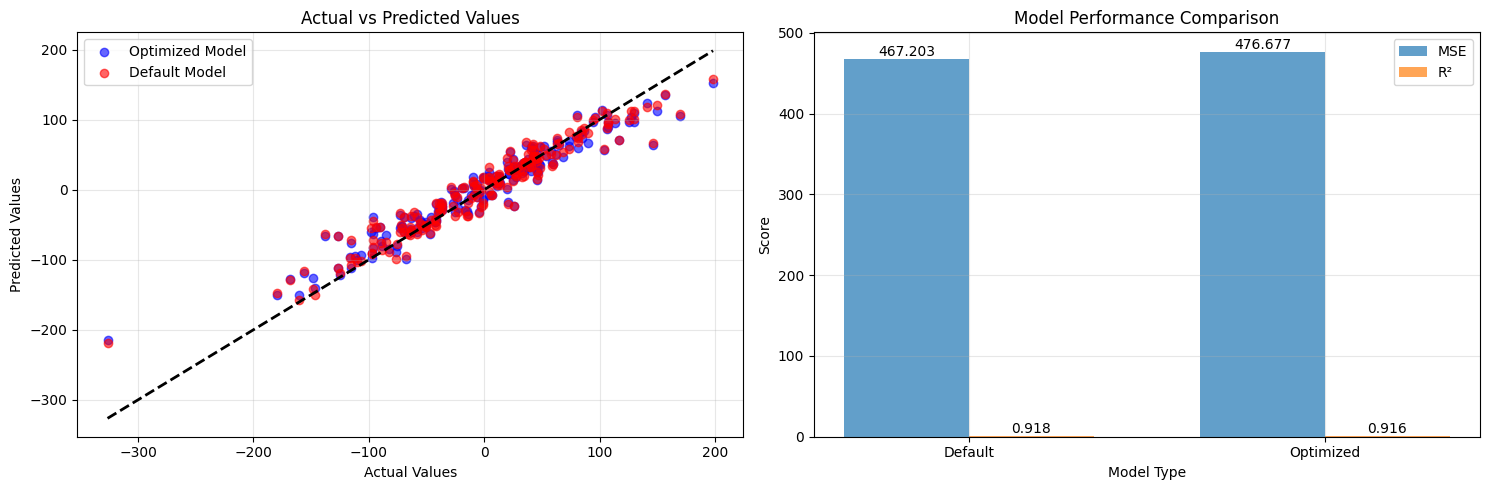


9. FEATURE IMPORTANCE FROM OPTIMIZED MODEL:
Top 5 Most Important Features:
     feature  importance
0   Factor_1    0.575300
8   Factor_9    0.191375
3   Factor_4    0.155355
6   Factor_7    0.019246
9  Factor_10    0.014119


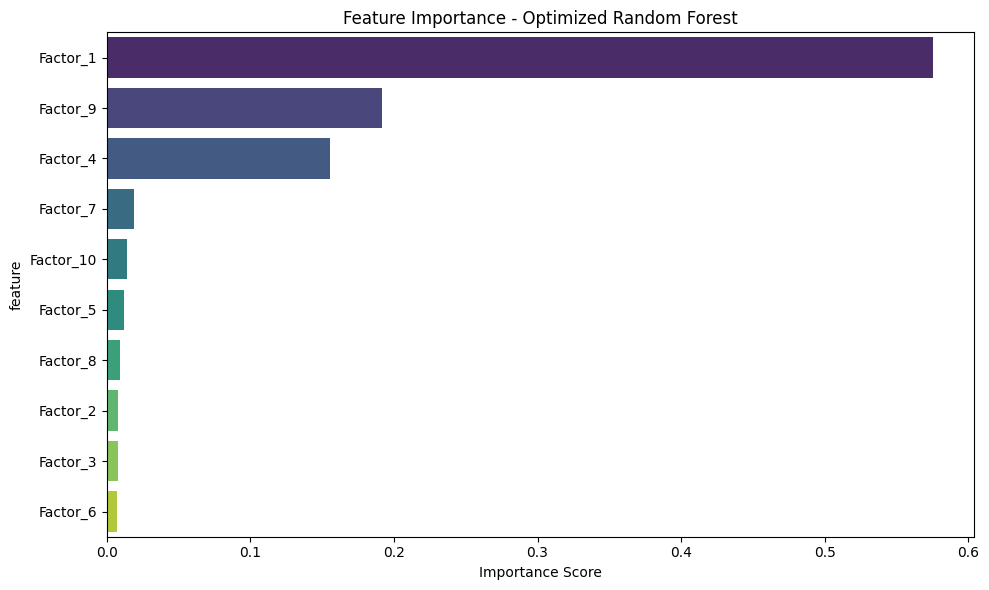


HYPERPARAMETER OPTIMIZATION COMPLETED SUCCESSFULLY!


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import make_regression
import warnings
warnings.filterwarnings('ignore')

print("=== HYPERPARAMETER OPTIMIZATION DEMONSTRATION ===\n")

# 1. GENERATE SYNTHETIC FINANCIAL DATASET
# Simulating asset returns based on multiple financial factors
print("1. Generating synthetic financial dataset...")
X, y = make_regression(n_samples=1000, n_features=10, n_informative=7,
                      noise=0.1, random_state=42)

# Create feature names to represent financial factors
feature_names = [f'Factor_{i+1}' for i in range(10)]
X = pd.DataFrame(X, columns=feature_names)
y = pd.Series(y, name='Asset_Returns')

print(f"Dataset shape: {X.shape}")
print(f"Target variable: {y.name}")
print(f"Features: {list(X.columns)}")

# 2. TRAIN-TEST SPLIT
print("\n2. Splitting data into training and testing sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

# 3. DEFINE THE MODEL AND HYPERPARAMETER DISTRIBUTIONS
print("\n3. Setting up Random Forest with hyperparameter distributions...")
rf_model = RandomForestRegressor(random_state=42)

# Define parameter distributions for Random Search
param_distributions = {
    'n_estimators': [50, 100, 200, 300, 500],           # Number of trees
    'max_depth': [None, 5, 10, 15, 20, 30],             # Maximum tree depth
    'min_samples_split': [2, 5, 10],                    # Minimum samples to split
    'min_samples_leaf': [1, 2, 4],                      # Minimum samples at leaf
    'max_features': ['auto', 'sqrt', 'log2', 0.7, 0.8], # Features to consider for splits
    'bootstrap': [True, False]                          # Bootstrap sampling
}

print("Hyperparameter distributions for Random Search:")
for param, values in param_distributions.items():
    print(f"  {param}: {values}")

# 4. PERFORM RANDOMIZED SEARCH WITH CROSS-VALIDATION
print("\n4. Performing Randomized Search with 5-fold Cross-Validation...")
random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_distributions,
    n_iter=50,                    # Number of parameter combinations to try
    cv=5,                         # 5-fold cross-validation
    scoring='neg_mean_squared_error',  # Metric to optimize
    n_jobs=-1,                    # Use all available processors
    random_state=42,
    verbose=1
)

# Fit the random search model
random_search.fit(X_train, y_train)

print("Randomized Search completed!")

# 5. DISPLAY OPTIMIZATION RESULTS
print("\n5. RANDOMIZED SEARCH RESULTS:")
print("=" * 50)
print(f"Best Cross-Validation Score (Negative MSE): {random_search.best_score_:.4f}")
print(f"Best Hyperparameters Found:")
best_params = random_search.best_params_
for param, value in best_params.items():
    print(f"  {param}: {value}")

# 6. EVALUATE THE OPTIMIZED MODEL ON TEST DATA
print("\n6. EVALUATING OPTIMIZED MODEL ON TEST SET:")
print("=" * 50)

# Get the best model from random search
best_rf_model = random_search.best_estimator_

# Make predictions on test set
y_pred = best_rf_model.predict(X_test)

# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test Set Performance:")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

# 7. COMPARE WITH DEFAULT MODEL
print("\n7. COMPARISON WITH DEFAULT PARAMETERS:")
print("=" * 50)

# Train model with default parameters
default_rf = RandomForestRegressor(random_state=42)
default_rf.fit(X_train, y_train)
y_pred_default = default_rf.predict(X_test)

mse_default = mean_squared_error(y_test, y_pred_default)
r2_default = r2_score(y_test, y_pred_default)

print(f"Default Model Performance:")
print(f"Mean Squared Error: {mse_default:.4f}")
print(f"R² Score: {r2_default:.4f}")

improvement_mse = ((mse_default - mse) / mse_default) * 100
improvement_r2 = ((r2 - r2_default) / abs(r2_default)) * 100

print(f"\nImprovement from Hyperparameter Optimization:")
print(f"MSE Improvement: {improvement_mse:+.2f}%")
print(f"R² Improvement: {improvement_r2:+.2f}%")

# 8. VISUALIZE RESULTS
print("\n8. Generating performance visualization...")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Actual vs Predicted values
axes[0].scatter(y_test, y_pred, alpha=0.6, color='blue', label='Optimized Model')
axes[0].scatter(y_test, y_pred_default, alpha=0.6, color='red', label='Default Model')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')
axes[0].set_title('Actual vs Predicted Values')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Performance comparison
models = ['Default', 'Optimized']
mse_scores = [mse_default, mse]
r2_scores = [r2_default, r2]

x = np.arange(len(models))
width = 0.35

bars1 = axes[1].bar(x - width/2, mse_scores, width, label='MSE', alpha=0.7)
bars2 = axes[1].bar(x + width/2, r2_scores, width, label='R²', alpha=0.7)

axes[1].set_xlabel('Model Type')
axes[1].set_ylabel('Score')
axes[1].set_title('Model Performance Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom')
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# 9. FEATURE IMPORTANCE FROM OPTIMIZED MODEL
print("\n9. FEATURE IMPORTANCE FROM OPTIMIZED MODEL:")
print("=" * 50)

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': best_rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 5 Most Important Features:")
print(feature_importance.head())

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance - Optimized Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("HYPERPARAMETER OPTIMIZATION COMPLETED SUCCESSFULLY!")
print("="*60)

### Optimizing the Bias-Variance Tradeoff

BIAS-VARIANCE TRADEOFF ANALYSIS
Dataset shape: (1000, 10)
Training set: 700 samples
Testing set: 300 samples
Generating Bias-Variance Analysis...


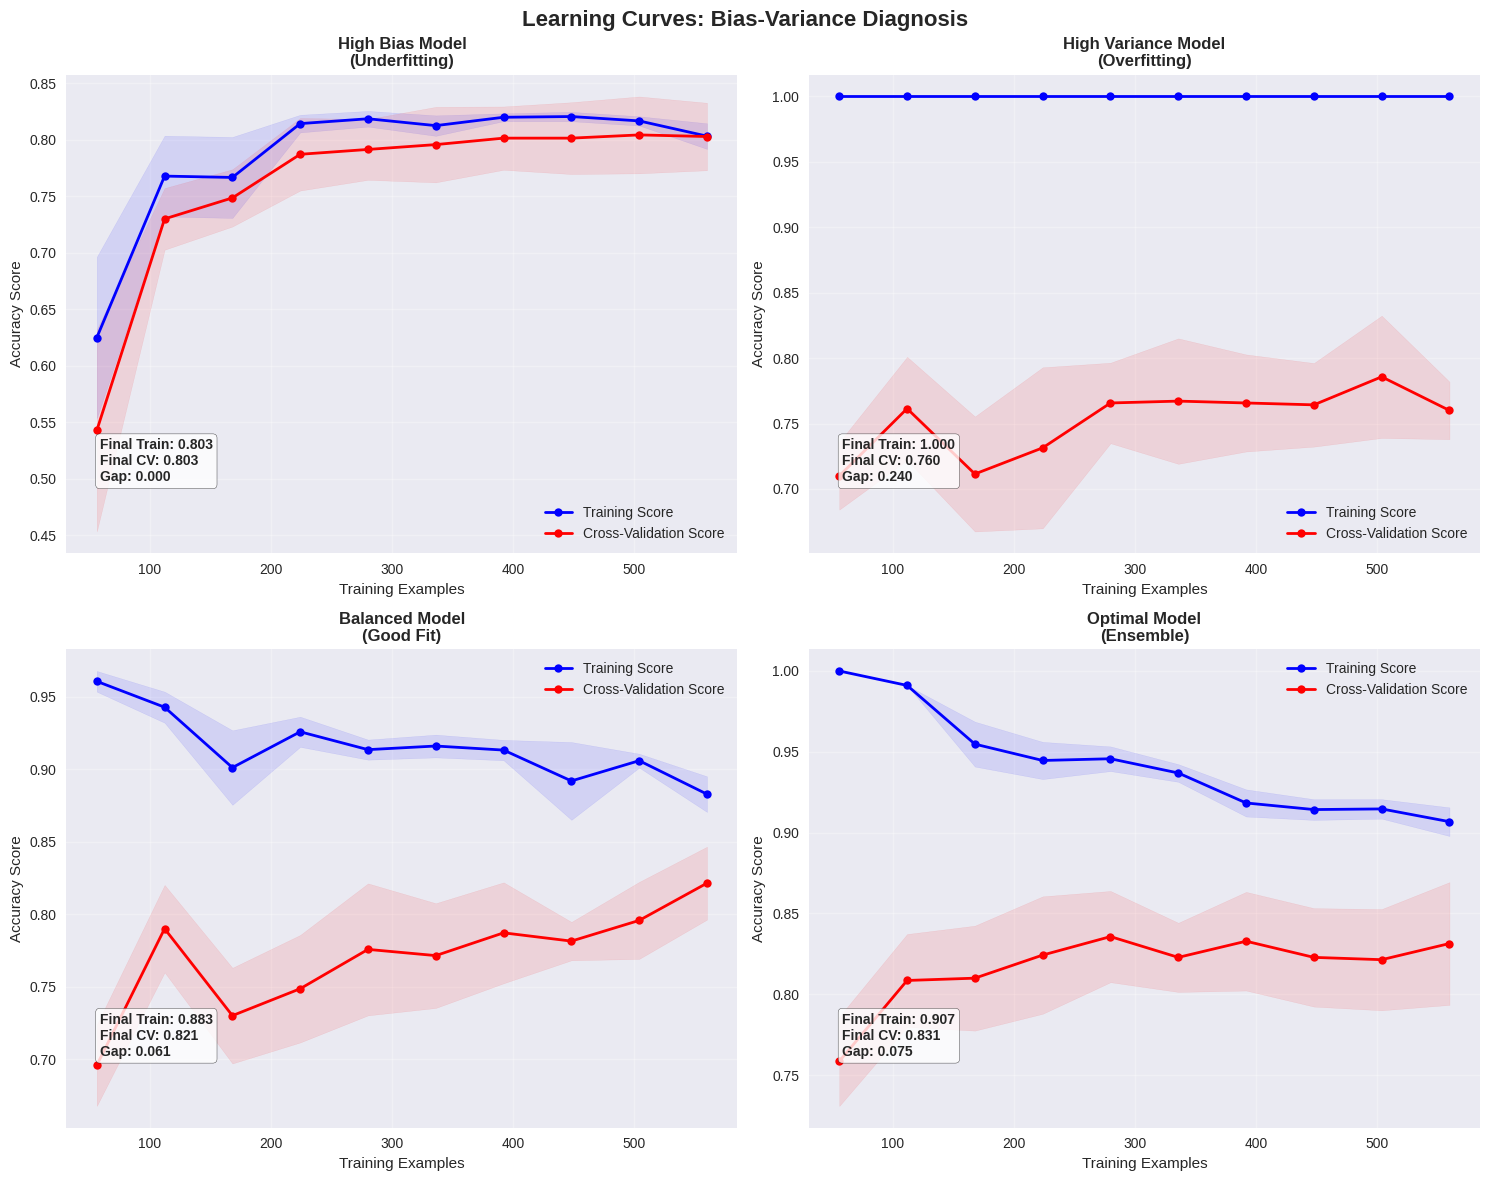

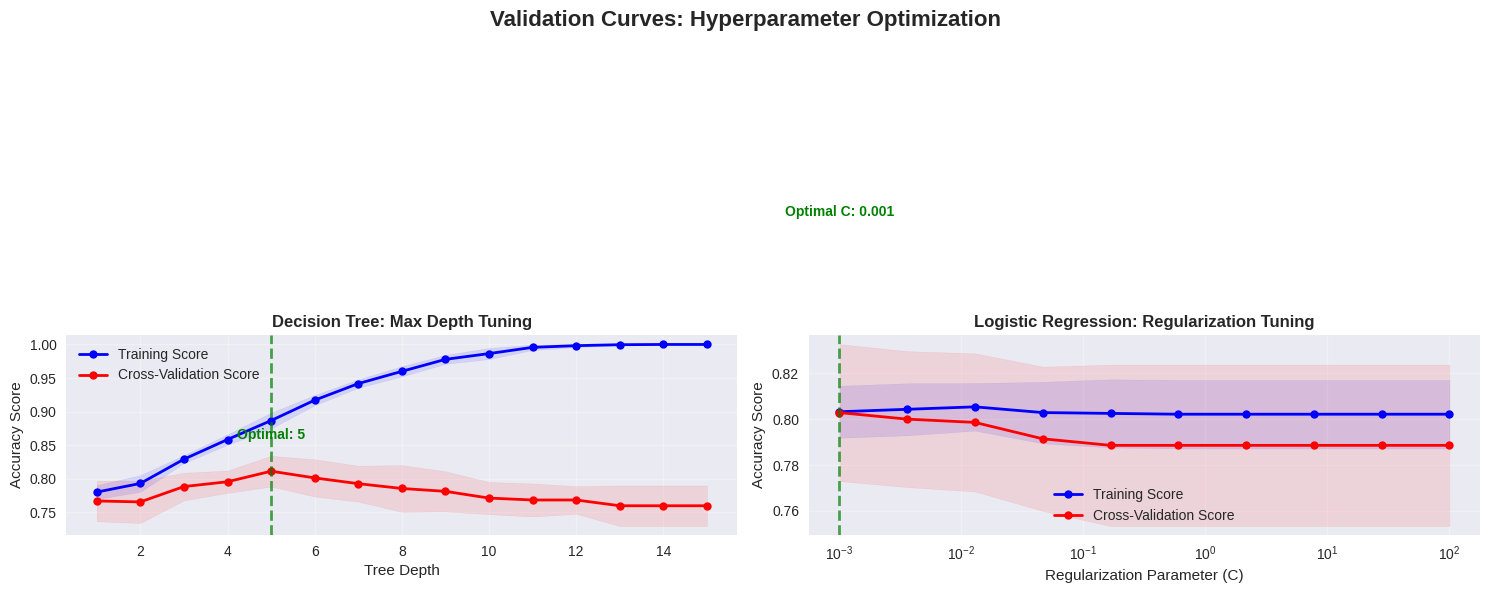

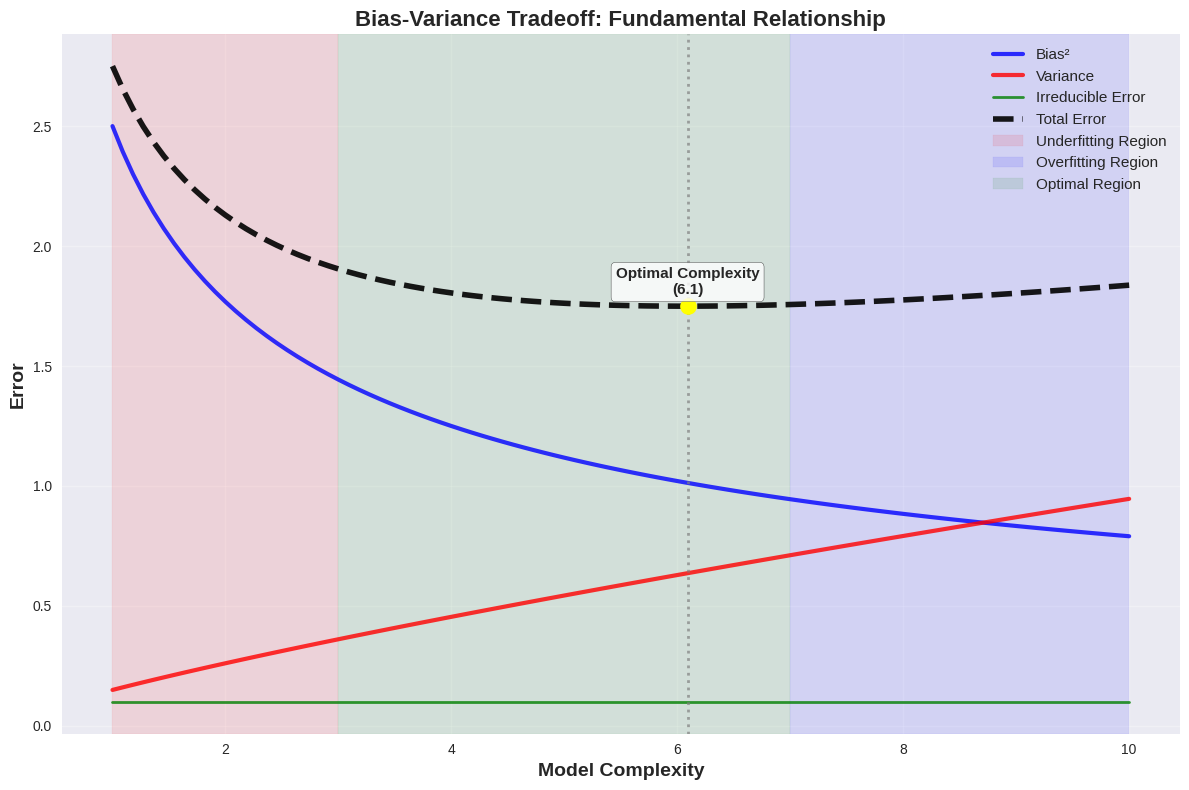


COMPREHENSIVE MODEL ANALYSIS

High Bias (Underfitting):
  Training Accuracy: 0.8057
  Testing Accuracy:  0.8033
  CV Accuracy:       0.8029 (±0.0597)
  Generalization Gap: 0.0024

High Variance (Overfitting):
  Training Accuracy: 1.0000
  Testing Accuracy:  0.8100
  CV Accuracy:       0.7671 (±0.0590)
  Generalization Gap: 0.1900

Balanced:
  Training Accuracy: 0.8929
  Testing Accuracy:  0.8333
  CV Accuracy:       0.8114 (±0.0500)
  Generalization Gap: 0.0595

Optimal (Random Forest):
  Training Accuracy: 0.8986
  Testing Accuracy:  0.8433
  CV Accuracy:       0.8314 (±0.0759)
  Generalization Gap: 0.0552


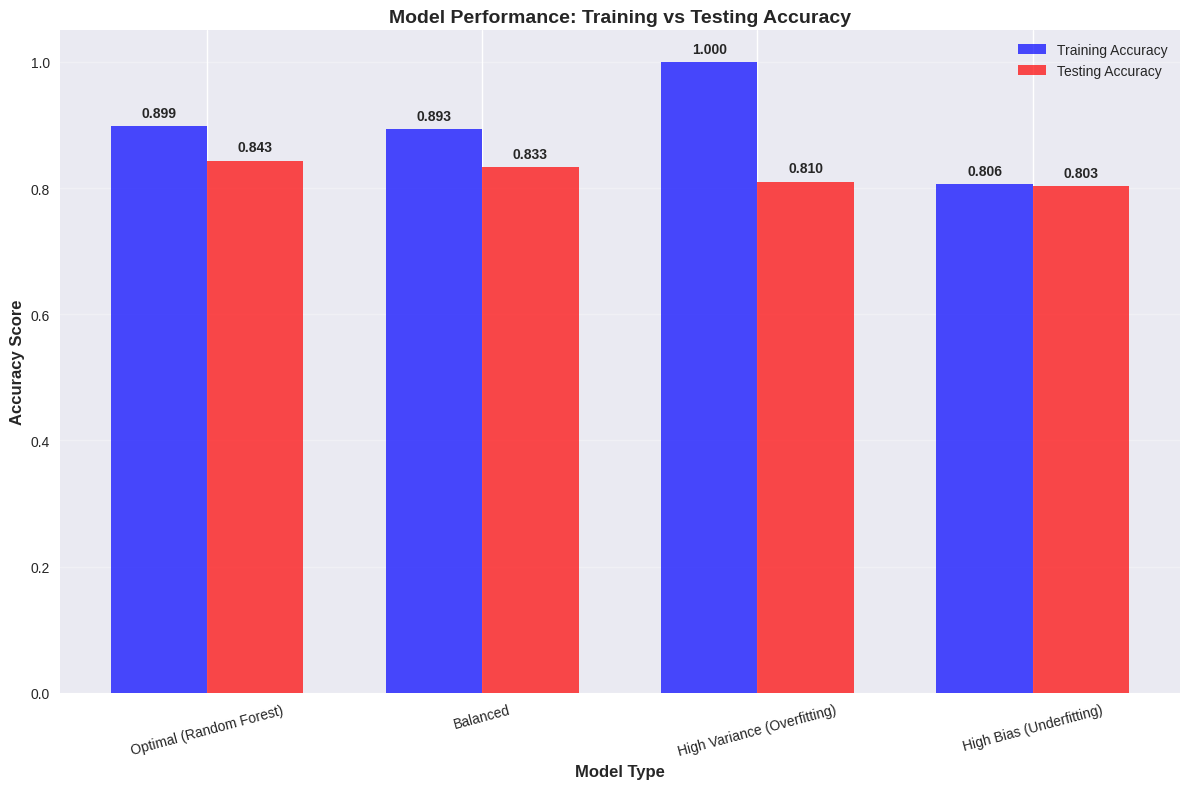


KEY FINDINGS SUMMARY - BIAS-VARIANCE TRADEOFF

OPTIMAL PARAMETERS FOUND:
• Decision Tree Optimal Depth: 5
• Logistic Regression Optimal C: 0.001
• Theoretical Optimal Complexity: 6.1

BIAS-VARIANCE PROFILES:
1. HIGH BIAS MODELS (Underfitting):
   - Simple models that are too rigid
   - Both training and test performance are poor
   - Solution: Increase model complexity, add features

2. HIGH VARIANCE MODELS (Overfitting):
   - Complex models that memorize noise
   - Excellent training performance, poor test performance
   - Solution: Regularization, simplify model, more data

3. BALANCED MODELS (Optimal):
   - Good performance on both training and test data
   - Small generalization gap
   - Ensembles often provide best balance

FINANCIAL IMPLICATIONS:
• Overfitting leads to false signals and poor out-of-sample performance
• Underfitting misses profitable opportunities
• Cross-validation is essential for reliable model selection
• Regularization helps prevent overfitting in financial 

In [2]:
# =============================================================================
# BIAS-VARIANCE TRADEOFF ANALYSIS
# Issue 2: Optimizing the Bias-Variance Tradeoff
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve, validation_curve, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("=" * 60)
print("BIAS-VARIANCE TRADEOFF ANALYSIS")
print("=" * 60)

# Create sample financial dataset (e.g., predicting stock movement)
X, y = make_classification(n_samples=1000, n_features=10, n_informative=6,
                          n_redundant=2, random_state=42, flip_y=0.05)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=42, stratify=y)

print(f"Dataset shape: {X.shape}")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

# =============================================================================
# 1. LEARNING CURVES FOR DIFFERENT MODELS
# =============================================================================

def plot_learning_curves():
    """Generate learning curves to diagnose bias vs variance"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Learning Curves: Bias-Variance Diagnosis', fontsize=16, fontweight='bold')

    # Define models with different bias-variance characteristics
    models = [
        ('High Bias Model\n(Underfitting)', LogisticRegression(C=0.001, max_iter=1000)),
        ('High Variance Model\n(Overfitting)', DecisionTreeClassifier(max_depth=15, min_samples_split=2)),
        ('Balanced Model\n(Good Fit)', DecisionTreeClassifier(max_depth=5, min_samples_split=10)),
        ('Optimal Model\n(Ensemble)', RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42))
    ]

    for idx, (title, model) in enumerate(models):
        train_sizes, train_scores, test_scores = learning_curve(
            model, X_train, y_train, cv=5, n_jobs=-1,
            train_sizes=np.linspace(0.1, 1.0, 10),
            scoring='accuracy', random_state=42
        )

        ax = axes[idx//2, idx%2]

        # Calculate mean and standard deviation
        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)
        test_std = np.std(test_scores, axis=1)

        # Plot learning curves
        ax.plot(train_sizes, train_mean, 'o-', color='blue',
                label='Training Score', linewidth=2, markersize=6)
        ax.plot(train_sizes, test_mean, 'o-', color='red',
                label='Cross-Validation Score', linewidth=2, markersize=6)

        # Plot confidence intervals
        ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                       alpha=0.1, color='blue')
        ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                       alpha=0.1, color='red')

        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Training Examples')
        ax.set_ylabel('Accuracy Score')
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)

        # Add final performance values
        final_train_score = train_mean[-1]
        final_test_score = test_mean[-1]
        gap = final_train_score - final_test_score

        ax.text(0.05, 0.15, f'Final Train: {final_train_score:.3f}\nFinal CV: {final_test_score:.3f}\nGap: {gap:.3f}',
                transform=ax.transAxes, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
                fontweight='bold')

    plt.tight_layout()
    plt.savefig('bias_variance_learning_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

# =============================================================================
# 2. VALIDATION CURVES FOR HYPERPARAMETER TUNING
# =============================================================================

def plot_validation_curves():
    """Generate validation curves for hyperparameter optimization"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('Validation Curves: Hyperparameter Optimization', fontsize=16, fontweight='bold')

    # Decision Tree Depth Validation Curve
    param_range = np.arange(1, 16)
    train_scores, test_scores = validation_curve(
        DecisionTreeClassifier(random_state=42),
        X_train, y_train,
        param_name="max_depth",
        param_range=param_range,
        cv=5, scoring="accuracy", n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    ax1.plot(param_range, train_mean, 'o-', color='blue',
             label="Training Score", linewidth=2, markersize=6)
    ax1.plot(param_range, test_mean, 'o-', color='red',
             label="Cross-Validation Score", linewidth=2, markersize=6)
    ax1.fill_between(param_range, train_mean - train_std, train_mean + train_std,
                    alpha=0.1, color='blue')
    ax1.fill_between(param_range, test_mean - test_std, test_mean + test_std,
                    alpha=0.1, color='red')

    # Mark optimal depth
    optimal_depth = param_range[np.argmax(test_mean)]
    ax1.axvline(x=optimal_depth, color='green', linestyle='--', alpha=0.7, linewidth=2)
    ax1.text(optimal_depth, test_mean.min() + 0.1, f'Optimal: {optimal_depth}',
             ha='center', fontweight='bold', color='green')

    ax1.set_title('Decision Tree: Max Depth Tuning', fontweight='bold')
    ax1.set_xlabel('Tree Depth')
    ax1.set_ylabel('Accuracy Score')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Regularization Parameter Validation Curve
    param_range = np.logspace(-3, 2, 10)
    train_scores, test_scores = validation_curve(
        LogisticRegression(random_state=42, max_iter=1000),
        X_train, y_train,
        param_name="C",
        param_range=param_range,
        cv=5, scoring="accuracy", n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    ax2.semilogx(param_range, train_mean, 'o-', color='blue',
                 label="Training Score", linewidth=2, markersize=6)
    ax2.semilogx(param_range, test_mean, 'o-', color='red',
                 label="Cross-Validation Score", linewidth=2, markersize=6)
    ax2.fill_between(param_range, train_mean - train_std, train_mean + train_std,
                    alpha=0.1, color='blue')
    ax2.fill_between(param_range, test_mean - test_std, test_mean + test_std,
                    alpha=0.1, color='red')

    # Mark optimal regularization
    optimal_C = param_range[np.argmax(test_mean)]
    ax2.axvline(x=optimal_C, color='green', linestyle='--', alpha=0.7, linewidth=2)
    ax2.text(optimal_C, test_mean.min() + 0.1, f'Optimal C: {optimal_C:.3f}',
             ha='center', fontweight='bold', color='green')

    ax2.set_title('Logistic Regression: Regularization Tuning', fontweight='bold')
    ax2.set_xlabel('Regularization Parameter (C)')
    ax2.set_ylabel('Accuracy Score')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('bias_variance_validation_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

    return optimal_depth, optimal_C

# =============================================================================
# 3. BIAS-VARIANCE TRADEOFF VISUALIZATION
# =============================================================================

def plot_bias_variance_tradeoff():
    """Visualize the fundamental bias-variance tradeoff"""
    plt.figure(figsize=(12, 8))

    # Simulate bias-variance tradeoff relationship
    complexity = np.linspace(1, 10, 100)

    # Mathematical relationships
    bias_squared = 2.5 / np.sqrt(complexity)  # Bias decreases with complexity
    variance = 0.15 * complexity**0.8         # Variance increases with complexity
    irreducible_error = 0.1 * np.ones_like(complexity)  # Constant noise
    total_error = bias_squared + variance + irreducible_error

    plt.plot(complexity, bias_squared, 'b-', linewidth=3, label='Bias²', alpha=0.8)
    plt.plot(complexity, variance, 'r-', linewidth=3, label='Variance', alpha=0.8)
    plt.plot(complexity, irreducible_error, 'g-', linewidth=2, label='Irreducible Error', alpha=0.8)
    plt.plot(complexity, total_error, 'k--', linewidth=4, label='Total Error', alpha=0.9)

    # Mark optimal complexity point
    optimal_idx = np.argmin(total_error)
    optimal_complexity = complexity[optimal_idx]
    min_total_error = total_error[optimal_idx]

    plt.axvline(x=optimal_complexity, color='gray', linestyle=':', alpha=0.7, linewidth=2)
    plt.plot(optimal_complexity, min_total_error, 'ko', markersize=12, markerfacecolor='yellow')

    # Annotations
    plt.text(optimal_complexity, min_total_error + 0.05,
             f'Optimal Complexity\n({optimal_complexity:.1f})',
             ha='center', fontweight='bold', fontsize=11,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    # Region annotations
    plt.axvspan(1, 3, alpha=0.1, color='red', label='Underfitting Region')
    plt.axvspan(7, 10, alpha=0.1, color='blue', label='Overfitting Region')
    plt.axvspan(3, 7, alpha=0.1, color='green', label='Optimal Region')

    plt.xlabel('Model Complexity', fontsize=14, fontweight='bold')
    plt.ylabel('Error', fontsize=14, fontweight='bold')
    plt.title('Bias-Variance Tradeoff: Fundamental Relationship',
              fontweight='bold', fontsize=16)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('bias_variance_tradeoff_diagram.png', dpi=300, bbox_inches='tight')
    plt.show()

    return optimal_complexity, min_total_error

# =============================================================================
# 4. COMPREHENSIVE MODEL COMPARISON
# =============================================================================

def comprehensive_model_analysis():
    """Compare different models and their bias-variance characteristics"""
    print("\n" + "=" * 50)
    print("COMPREHENSIVE MODEL ANALYSIS")
    print("=" * 50)

    models = {
        'High Bias (Underfitting)': LogisticRegression(C=0.001, max_iter=1000),
        'High Variance (Overfitting)': DecisionTreeClassifier(max_depth=15, min_samples_split=2),
        'Balanced': DecisionTreeClassifier(max_depth=5, min_samples_split=10),
        'Optimal (Random Forest)': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
    }

    results = []

    for model_name, model in models.items():
        # Train the model
        model.fit(X_train, y_train)

        # Calculate scores
        train_score = accuracy_score(y_train, model.predict(X_train))
        test_score = accuracy_score(y_test, model.predict(X_test))

        # Cross-validation scores
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std()

        # Bias-Variance assessment
        bias_indicator = 1 - train_score  # Approximation of bias
        variance_indicator = train_score - test_score  # Approximation of variance

        results.append({
            'Model': model_name,
            'Train Accuracy': train_score,
            'Test Accuracy': test_score,
            'CV Mean': cv_mean,
            'CV Std': cv_std,
            'Bias Indicator': bias_indicator,
            'Variance Indicator': variance_indicator,
            'Generalization Gap': train_score - test_score
        })

        print(f"\n{model_name}:")
        print(f"  Training Accuracy: {train_score:.4f}")
        print(f"  Testing Accuracy:  {test_score:.4f}")
        print(f"  CV Accuracy:       {cv_mean:.4f} (±{cv_std*2:.4f})")
        print(f"  Generalization Gap: {train_score - test_score:.4f}")

    # Create results DataFrame
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Test Accuracy', ascending=False)

    # Plot comparison
    plt.figure(figsize=(12, 8))

    # Model performance comparison
    models_list = results_df['Model'].values
    train_scores = results_df['Train Accuracy'].values
    test_scores = results_df['Test Accuracy'].values

    x = np.arange(len(models_list))
    width = 0.35

    plt.bar(x - width/2, train_scores, width, label='Training Accuracy',
            alpha=0.7, color='blue')
    plt.bar(x + width/2, test_scores, width, label='Testing Accuracy',
            alpha=0.7, color='red')

    plt.xlabel('Model Type', fontsize=12, fontweight='bold')
    plt.ylabel('Accuracy Score', fontsize=12, fontweight='bold')
    plt.title('Model Performance: Training vs Testing Accuracy', fontsize=14, fontweight='bold')
    plt.xticks(x, models_list, rotation=15)
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for i, (train, test) in enumerate(zip(train_scores, test_scores)):
        plt.text(i - width/2, train + 0.01, f'{train:.3f}', ha='center', va='bottom', fontweight='bold')
        plt.text(i + width/2, test + 0.01, f'{test:.3f}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.savefig('model_performance_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    return results_df

# =============================================================================
# 5. EXECUTE ALL ANALYSES
# =============================================================================

print("Generating Bias-Variance Analysis...")

# Generate all visualizations
plot_learning_curves()
optimal_depth, optimal_C = plot_validation_curves()
optimal_complexity, min_error = plot_bias_variance_tradeoff()
results_df = comprehensive_model_analysis()

# =============================================================================
# 6. SUMMARY AND KEY INSIGHTS
# =============================================================================

print("\n" + "=" * 60)
print("KEY FINDINGS SUMMARY - BIAS-VARIANCE TRADEOFF")
print("=" * 60)

print(f"""
OPTIMAL PARAMETERS FOUND:
• Decision Tree Optimal Depth: {optimal_depth}
• Logistic Regression Optimal C: {optimal_C:.3f}
• Theoretical Optimal Complexity: {optimal_complexity:.1f}

BIAS-VARIANCE PROFILES:
1. HIGH BIAS MODELS (Underfitting):
   - Simple models that are too rigid
   - Both training and test performance are poor
   - Solution: Increase model complexity, add features

2. HIGH VARIANCE MODELS (Overfitting):
   - Complex models that memorize noise
   - Excellent training performance, poor test performance
   - Solution: Regularization, simplify model, more data

3. BALANCED MODELS (Optimal):
   - Good performance on both training and test data
   - Small generalization gap
   - Ensembles often provide best balance

FINANCIAL IMPLICATIONS:
• Overfitting leads to false signals and poor out-of-sample performance
• Underfitting misses profitable opportunities
• Cross-validation is essential for reliable model selection
• Regularization helps prevent overfitting in financial models

RECOMMENDED STRATEGY:
1. Use cross-validation for model selection
2. Monitor learning curves during development
3. Implement regularization techniques
4. Prefer ensemble methods for better bias-variance balance
5. Validate on out-of-sample financial data
""")

# Save detailed results
results_df.to_csv('bias_variance_analysis_results.csv', index=False)
print("\nDetailed results saved to 'bias_variance_analysis_results.csv'")

print("\n" + "=" * 50)
print("VISUALIZATIONS GENERATED:")
print("1. bias_variance_learning_curves.png")
print("2. bias_variance_validation_curves.png")
print("3. bias_variance_tradeoff_diagram.png")
print("4. model_performance_comparison.png")
print("=" * 50)

### Applying Ensemble learning - Bagging, Boosting, or stacking

In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report


df = pd.read_csv("breast_cancer_dataset.csv")

# Split features and target
X = df.drop('target', axis=1)
y = df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --------------------------
# Bagging Classifier (updated for scikit-learn 1.2+)
# --------------------------
bagging_model = BaggingClassifier(
    estimator=RandomForestClassifier(n_estimators=10, random_state=42),
    n_estimators=50,
    random_state=42
)
bagging_model.fit(X_train, y_train)
y_pred_bag = bagging_model.predict(X_test)
print("=== Bagging Classifier ===")
print("Accuracy:", accuracy_score(y_test, y_pred_bag))
print(classification_report(y_test, y_pred_bag))

# --------------------------
# Boosting Classifier (AdaBoost)
# --------------------------
boosting_model = AdaBoostClassifier(
    estimator=RandomForestClassifier(n_estimators=10, random_state=42),
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)
boosting_model.fit(X_train, y_train)
y_pred_boost = boosting_model.predict(X_test)
print("=== Boosting Classifier ===")
print("Accuracy:", accuracy_score(y_test, y_pred_boost))
print(classification_report(y_test, y_pred_boost))

# --------------------------
# Stacking Classifier
# --------------------------
base_models = [
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('svm', SVC(probability=True, random_state=42))
]

stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression()
)
stacking_model.fit(X_train, y_train)
y_pred_stack = stacking_model.predict(X_test)
print("=== Stacking Classifier ===")
print("Accuracy:", accuracy_score(y_test, y_pred_stack))
print(classification_report(y_test, y_pred_stack))

# --------------------------
# Compare all models using cross-validation
# --------------------------
models = {
    "Bagging": bagging_model,
    "Boosting": boosting_model,
    "Stacking": stacking_model
}

print("=== Cross-Validation Scores ===")
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print(f"{name}: Mean Accuracy = {scores.mean():.4f}, Std = {scores.std():.4f}")
